In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns




from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor



from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error
)



In [32]:

# =============================================
# 2. LOAD REALISTIC DATASET
# =============================================
df = pd.read_excel("IT_resume_dataset_realistic.xlsx")

print("Dataset Loaded:", df.shape)
df.head()



Dataset Loaded: (10000, 6)


,Name,Experience_Years,Skills,Education,Applied_Job_Role,Salary_USD
0,Candidate_1,6.895116,"JIRA, Scrum, Agile, Retrospective, Sprint Plan...",BCA,Software Engineer,90991.913908
1,Candidate_2,17.019543,"Git, AWS, Node.js, React, Express, MongoDB",BSc Computer Science,Full Stack Developer,196796.492783
2,Candidate_3,18.862661,"SQL, Pandas, TensorFlow, Python, Scikit-learn",BCA,Data Scientist,198247.590322
3,Candidate_4,2.878788,"AWS, Docker, CI/CD, Kubernetes",BCA,AI Engineer,76193.089740
4,Candidate_5,0.286129,"Active Directory, Backup, Shell Scripting, VMware",Diploma in IT,System Administrator,59526.816535


 EXPLORATORY DATA ANALYSIS


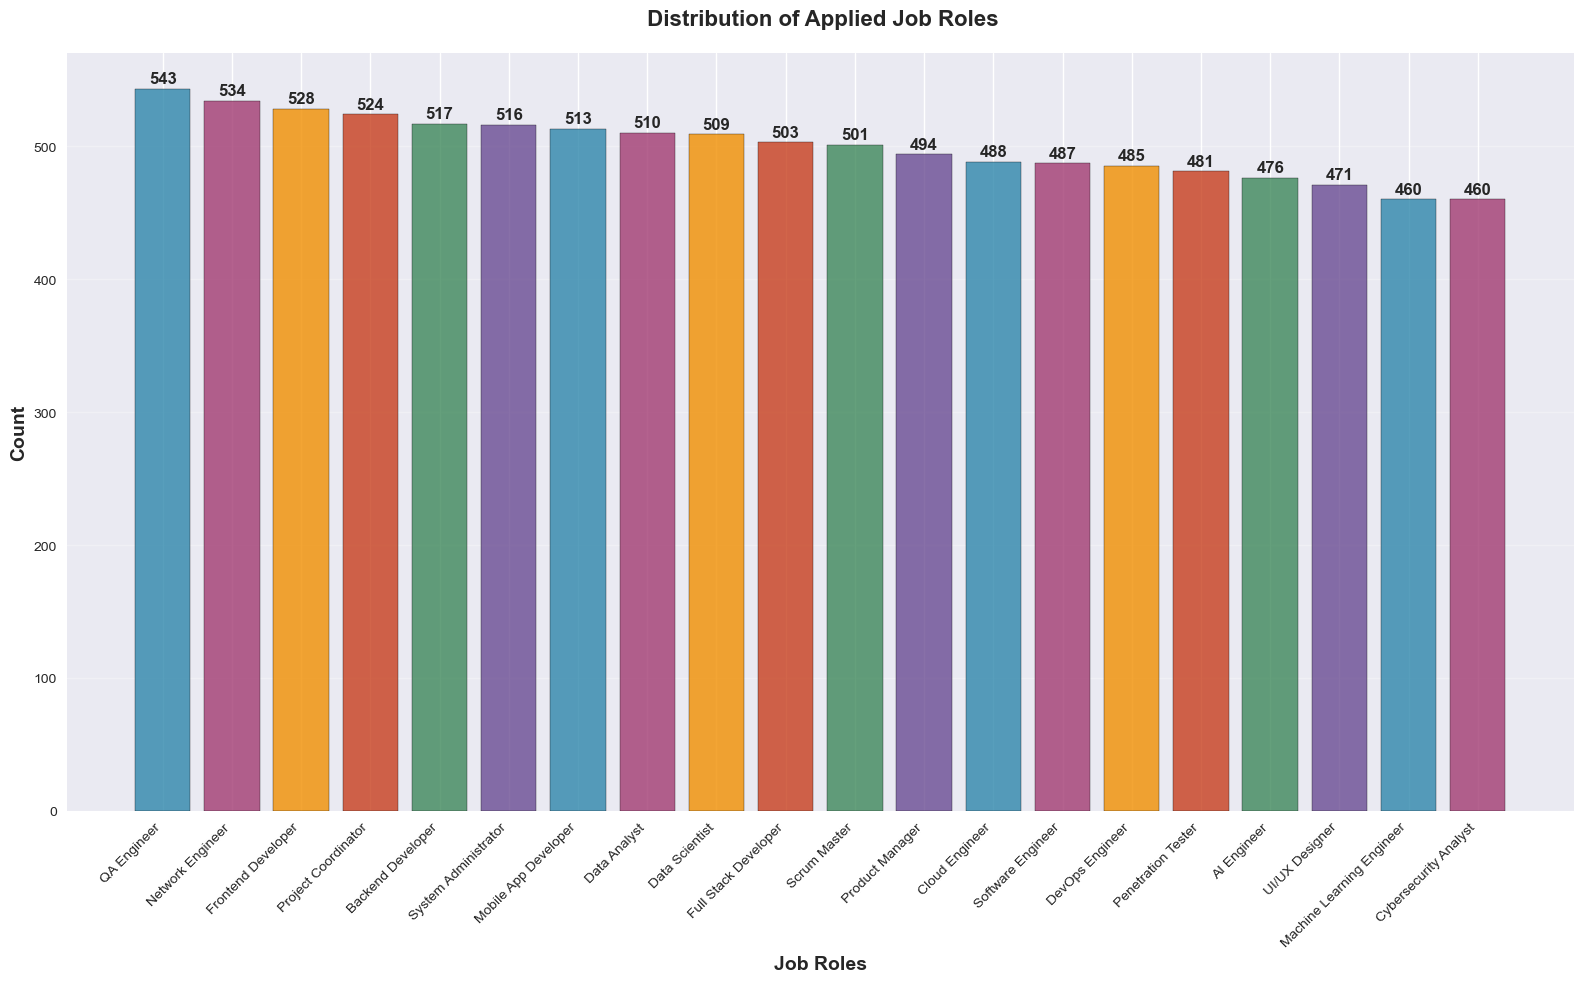

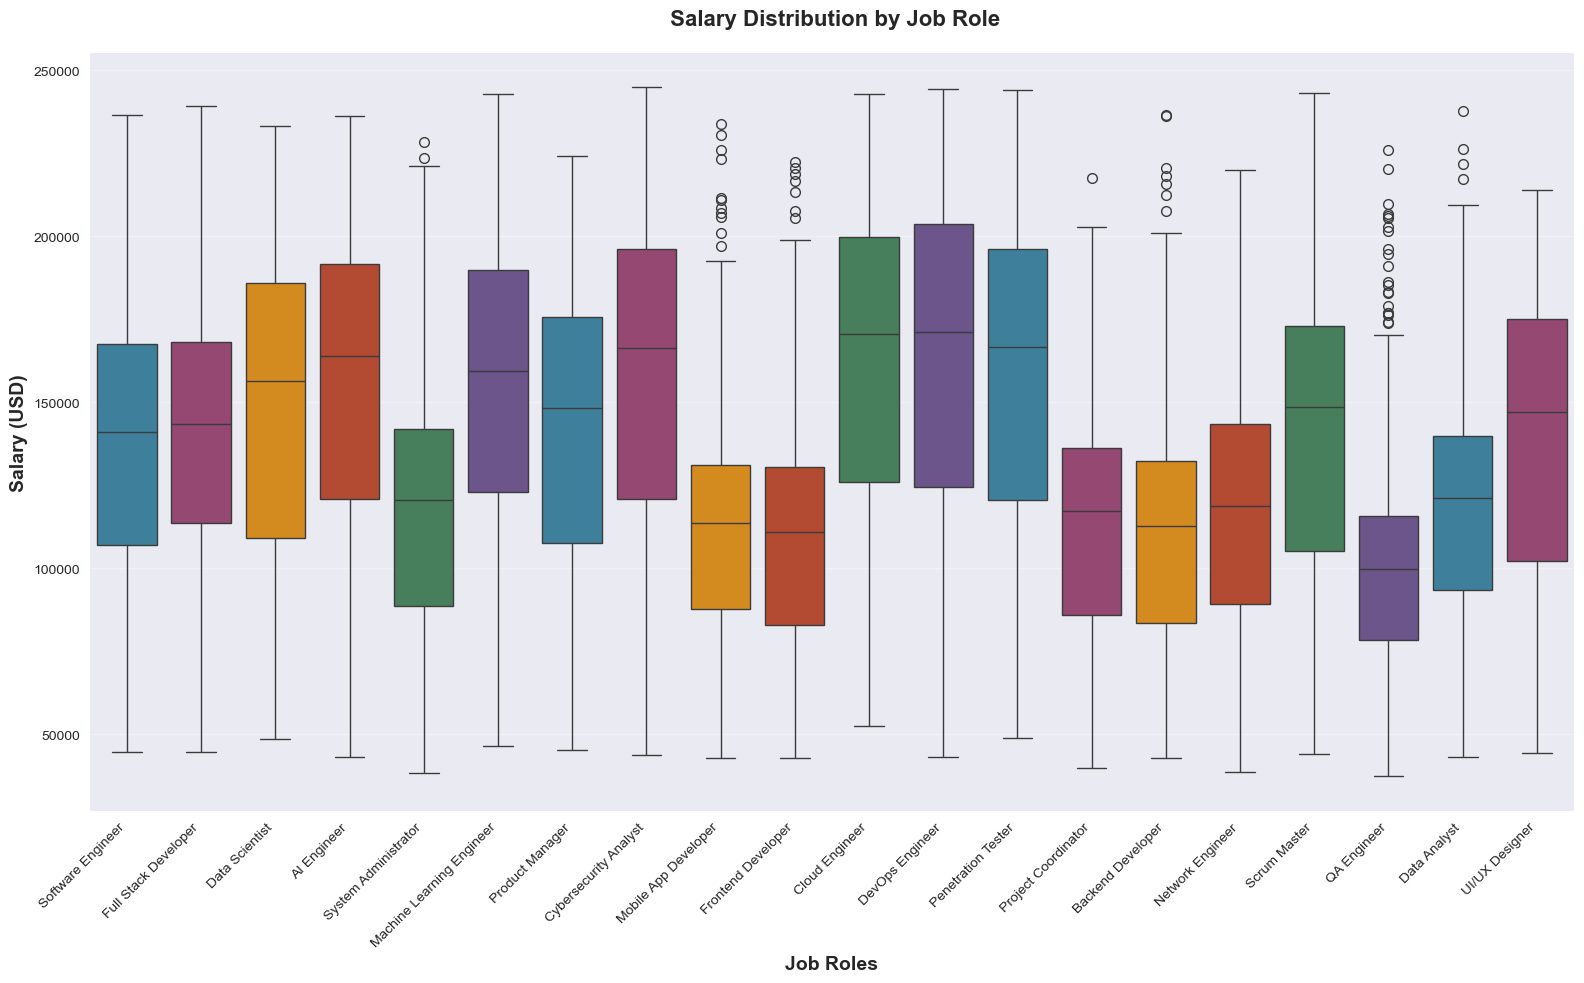

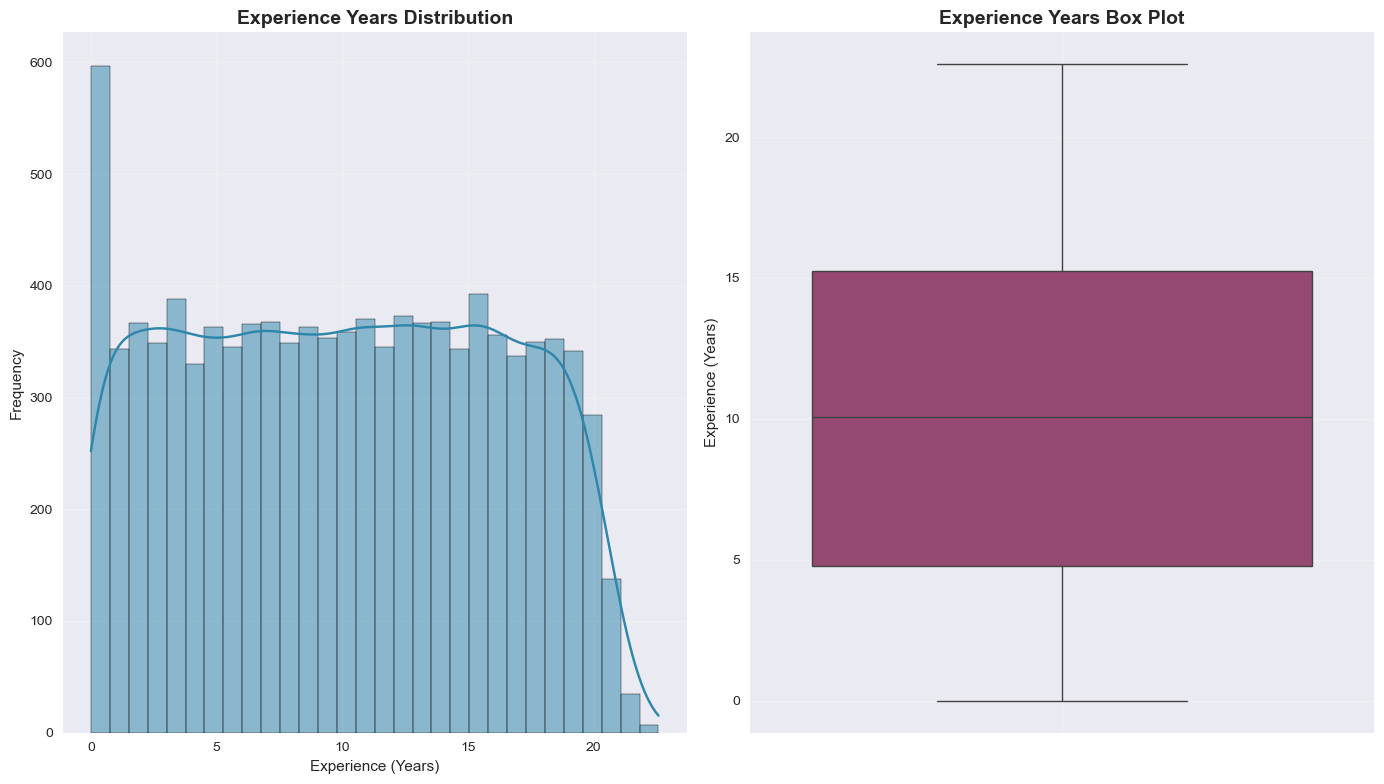


 Analyzing Top Skills...


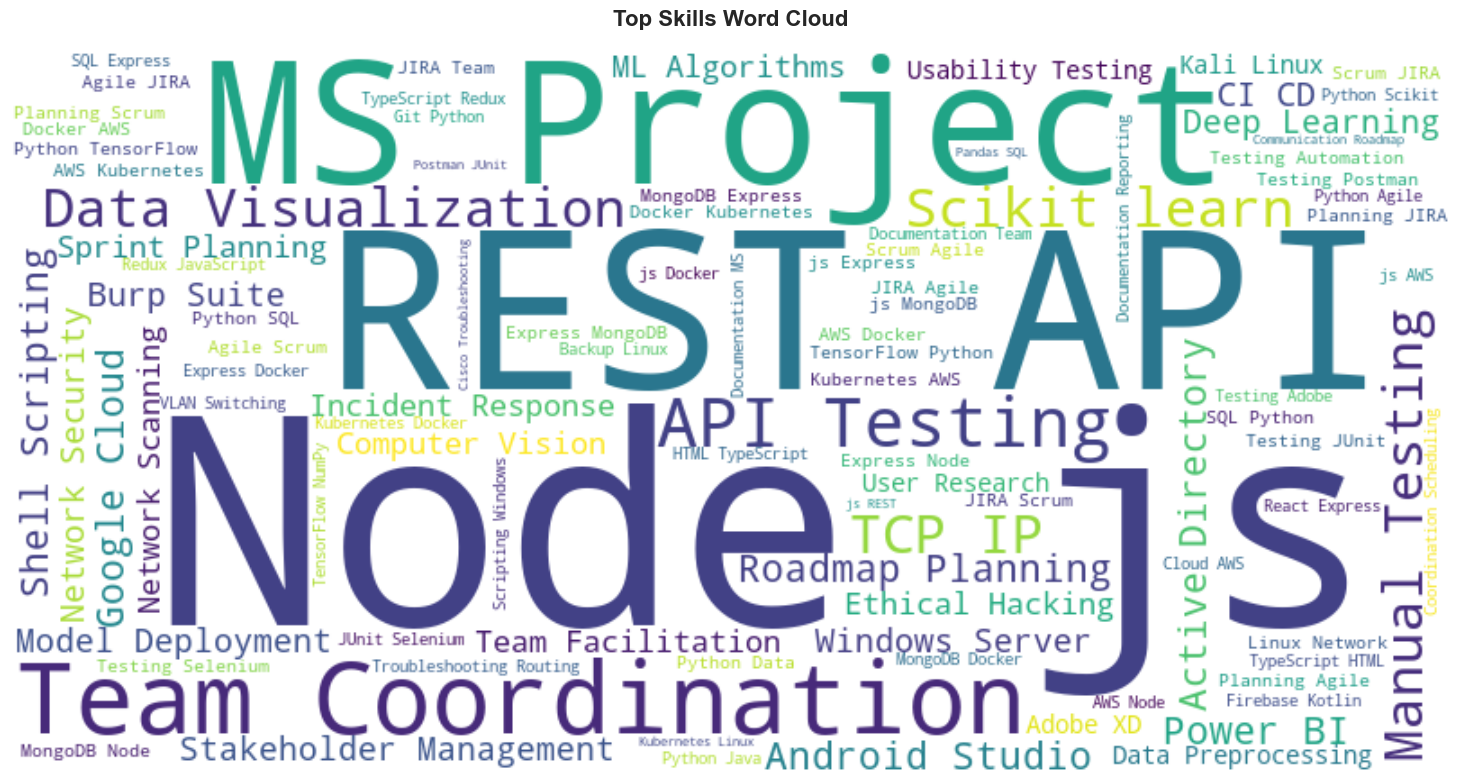

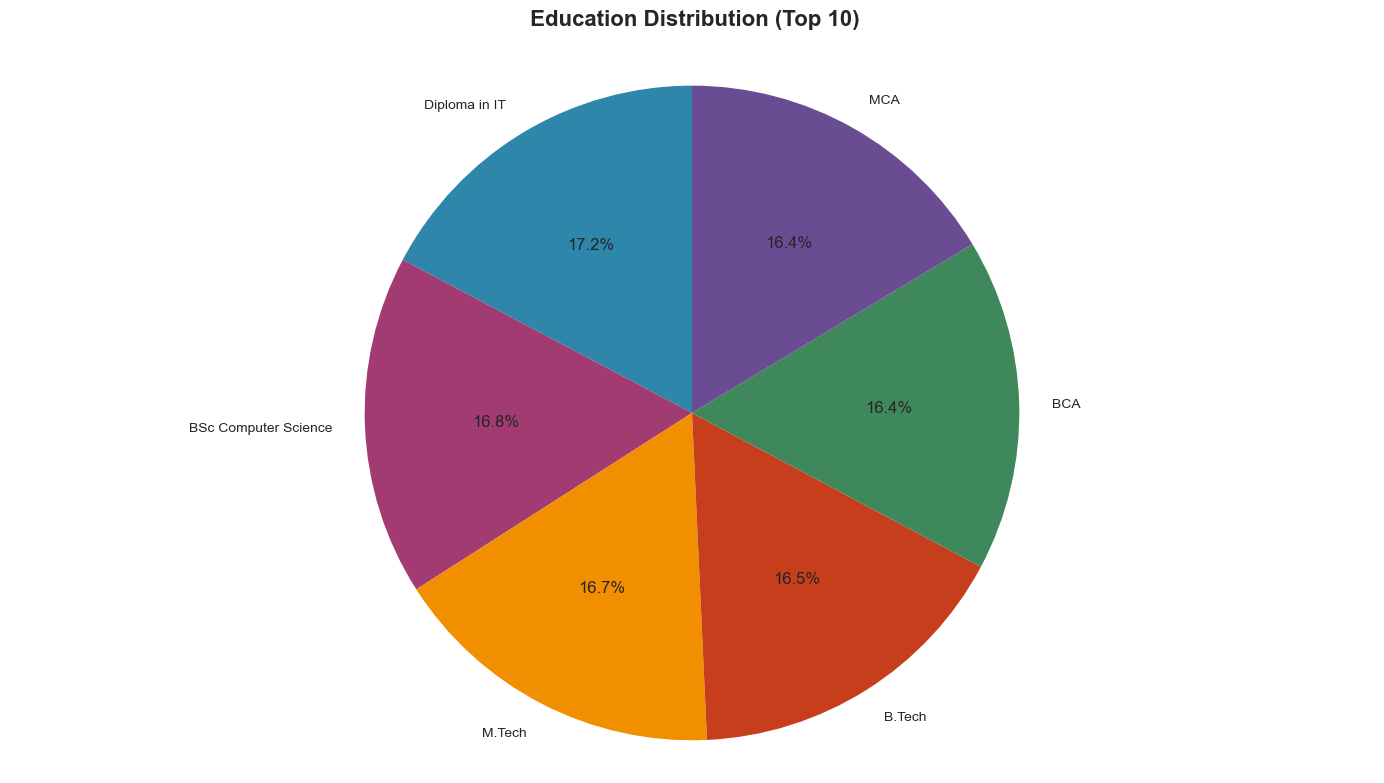

 Exploratory Data Analysis Complete!


In [33]:
# =============================================
# 2.5. EXPLORATORY DATA ANALYSIS VISUALIZATIONS
# =============================================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3E885B', '#6A4C93']

print(" EXPLORATORY DATA ANALYSIS")
print("=" * 50)

# 1. Distribution of Job Roles
plt.figure(figsize=(16, 10))
job_counts = df['Applied_Job_Role'].value_counts()
bars = plt.bar(job_counts.index, job_counts.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.title(' Distribution of Applied Job Roles', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Job Roles', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Salary Distribution by Job Role
plt.figure(figsize=(16, 10))
sns.boxplot(data=df, x='Applied_Job_Role', y='Salary_USD', palette=colors)
plt.title(' Salary Distribution by Job Role', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Job Roles', fontsize=14, fontweight='bold')
plt.ylabel('Salary (USD)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Experience Years Distribution
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
sns.histplot(df['Experience_Years'], bins=30, kde=True, color=colors[0])
plt.title('Experience Years Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Experience (Years)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Experience_Years'], color=colors[1])
plt.title('Experience Years Box Plot', fontsize=14, fontweight='bold')
plt.ylabel('Experience (Years)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Top Skills Word Cloud
print("\n Analyzing Top Skills...")
all_skills = ' '.join(df['Skills'].dropna()).replace(',', ' ')
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='viridis', max_words=100).generate(all_skills)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Skills Word Cloud', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 5. Education Distribution
plt.figure(figsize=(14, 8))
edu_counts = df['Education'].value_counts().head(10)
wedges, texts, autotexts = plt.pie(edu_counts.values, labels=edu_counts.index, 
                                   colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(' Education Distribution (Top 10)', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

print(" Exploratory Data Analysis Complete!")
print("=" * 50)

In [34]:
# =============================================
# 3. DEFINE FEATURES & TARGET
# =============================================
# Features for both models
X = df[["Skills", "Education", "Experience_Years"]]

# Target for Model 1 (Classification)
y_job = df["Applied_Job_Role"]

# Target for Model 2 (Regression)
y_salary = df["Salary_USD"]

# Train/Test split (same split for both models to keep consistency)
X_train, X_test, y_job_train, y_job_test, y_salary_train, y_salary_test = train_test_split(
    X, y_job, y_salary, test_size=0.20, random_state=42, stratify=y_job
)


In [35]:
# =============================================
# 4. PREPROCESSING (TF-IDF + SCALER)
# =============================================
skills_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

edu_tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2)
)

preprocessor = ColumnTransformer(
    transformers=[
        ("skills_vec", skills_tfidf, "Skills"),
        ("edu_vec", edu_tfidf, "Education"),
        ("exp_scale", StandardScaler(), ["Experience_Years"])
    ]
)



In [36]:
job_clf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1
)

job_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", job_clf)
])

print("Training Job Role Classifier...")
job_pipeline.fit(X_train, y_job_train)
print("Job Role Model Trained!")


Training Job Role Classifier...
Job Role Model Trained!


In [37]:
y_job_pred = job_pipeline.predict(X_test)

job_acc = accuracy_score(y_job_test, y_job_pred)
print("Job Prediction Accuracy:", job_acc)

print("\nClassification Report:\n")
print(classification_report(y_job_test, y_job_pred))


Job Prediction Accuracy: 0.895

Classification Report:

                           precision    recall  f1-score   support

              AI Engineer       0.87      0.91      0.89        95
        Backend Developer       0.88      0.91      0.90       103
           Cloud Engineer       0.92      0.89      0.91        97
    Cybersecurity Analyst       0.85      0.89      0.87        92
             Data Analyst       0.89      0.92      0.90       102
           Data Scientist       0.87      0.88      0.88       102
          DevOps Engineer       0.92      0.79      0.85        97
       Frontend Developer       0.88      0.87      0.88       106
     Full Stack Developer       0.88      0.89      0.89       101
Machine Learning Engineer       0.96      0.89      0.93        92
     Mobile App Developer       0.89      0.90      0.90       103
         Network Engineer       0.89      0.91      0.90       107
       Penetration Tester       0.90      0.90      0.90        96
     

In [38]:
job_model_path = "job_role_classifier.pkl"
joblib.dump(job_pipeline, job_model_path)

print("Job prediction model saved:", job_model_path)


Job prediction model saved: job_role_classifier.pkl


In [39]:
salary_reg = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    n_jobs=-1
)

salary_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", salary_reg)
])

print("Training Salary Prediction Model...")
salary_pipeline.fit(X_train, y_salary_train)
print("Salary Model Trained!")



Training Salary Prediction Model...
Salary Model Trained!


In [40]:
salary_pred = salary_pipeline.predict(X_test)

mae = mean_absolute_error(y_salary_test, salary_pred)
mse = mean_squared_error(y_salary_test, salary_pred)
rmse = np.sqrt(mse)

print("Salary Prediction Evaluation:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)


Salary Prediction Evaluation:
MAE : 12232.274434587147
MSE : 252265584.1230665
RMSE: 15882.870777131775


In [41]:
MODEL_PATH = "salary_prediction_model.pkl"

joblib.dump(salary_pipeline, MODEL_PATH)

print("Salary model saved as:", MODEL_PATH)


Salary model saved as: salary_prediction_model.pkl


In [46]:
def predict_job_and_salary(skills, education, experience):
    # Prepare a one-row input dataframe
    data = pd.DataFrame([{
        "Skills": skills,
        "Education": education,
        "Experience_Years": experience
    }])
    
    job_result = job_pipeline.predict(data)[0]
    salary_result = salary_pipeline.predict(data)[0]

    return job_result, round(salary_result, 2)

# Test example
predict_job_and_salary(
    "machine learning enginrering",
    "B.Tech",
    1
)


('AI Engineer', np.float64(62164.19))

 FINAL MODEL DASHBOARD


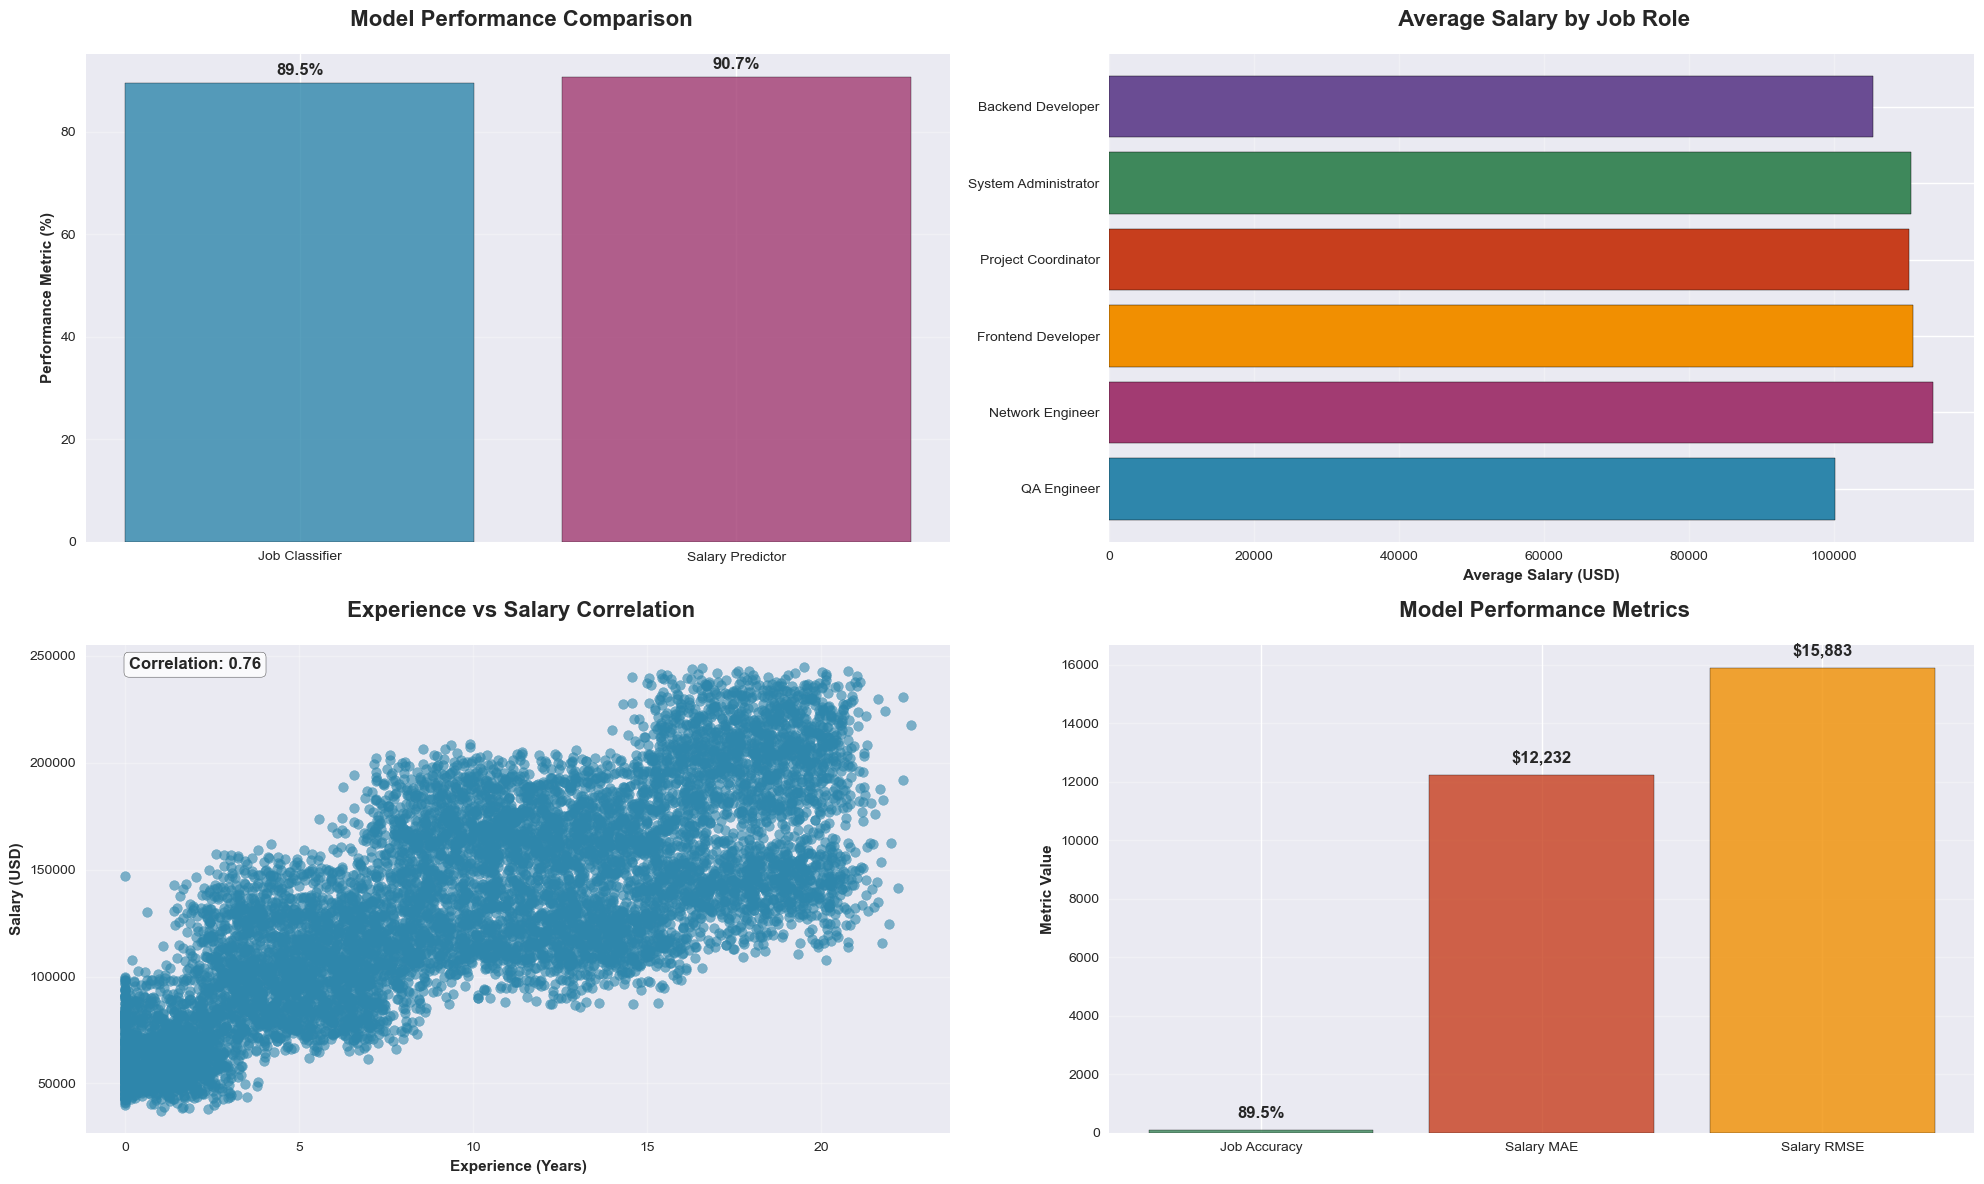

In [47]:
# =============================================
# 12. COMPREHENSIVE RESULTS DASHBOARD
# =============================================
print(" FINAL MODEL DASHBOARD")
print("=" * 50)

# Create a comprehensive summary visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

# 1. Model Accuracy Comparison
models = ['Job Classifier', 'Salary Predictor']
accuracies = [job_acc * 100, (1 - (mae / y_salary_test.mean())) * 100]
colors_acc = ['#2E86AB', '#A23B72']

bars1 = ax1.bar(models, accuracies, color=colors_acc, edgecolor='black', alpha=0.8)
ax1.set_title(' Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Performance Metric (%)', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 2. Salary Prediction Range by Job Role
job_salary_pred = X_test.copy()
job_salary_pred['Actual_Job'] = y_job_test
job_salary_pred['Predicted_Job'] = y_job_pred
job_salary_pred['Actual_Salary'] = y_salary_test
job_salary_pred['Predicted_Salary'] = salary_pred

top_jobs = job_salary_pred['Actual_Job'].value_counts().index[:6]
job_salary_means = job_salary_pred.groupby('Actual_Job')['Actual_Salary'].mean().loc[top_jobs]

ax2.barh(range(len(top_jobs)), job_salary_means.values, color=colors, edgecolor='black')
ax2.set_yticks(range(len(top_jobs)))
ax2.set_yticklabels(top_jobs)
ax2.set_xlabel('Average Salary (USD)', fontweight='bold')
ax2.set_title(' Average Salary by Job Role', fontsize=16, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3)

# 3. Experience vs Salary
ax3.scatter(df['Experience_Years'], df['Salary_USD'], alpha=0.6, color=colors[0])
ax3.set_xlabel('Experience (Years)', fontweight='bold')
ax3.set_ylabel('Salary (USD)', fontweight='bold')
ax3.set_title(' Experience vs Salary Correlation', fontsize=16, fontweight='bold', pad=20)
ax3.grid(alpha=0.3)

# Add correlation coefficient
correlation = df['Experience_Years'].corr(df['Salary_USD'])
ax3.text(0.05, 0.95, f'Correlation: {correlation:.2f}', 
         transform=ax3.transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# 4. Model Success Summary
success_metrics = ['Job Accuracy', 'Salary MAE', 'Salary RMSE']
success_values = [job_acc * 100, mae, rmse]
success_colors = ['#3E885B', '#C73E1D', '#F18F01']

bars4 = ax4.bar(success_metrics, success_values, color=success_colors, edgecolor='black', alpha=0.8)
ax4.set_title(' Model Performance Metrics', fontsize=16, fontweight='bold', pad=20)
ax4.set_ylabel('Metric Value', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar, metric in zip(bars4, success_metrics):
    height = bar.get_height()
    if metric == 'Job Accuracy':
        label = f'{height:.1f}%'
    else:
        label = f'${height:,.0f}'
    ax4.text(bar.get_x() + bar.get_width()/2., height + (0.02 * max(success_values)),
             label, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


